# Model 6 — DistilBERT Multi-Seed + TF-IDF Soft-Voting Ensemble

**Starting point:** model4 DistilBERT = **98.4%** — we keep its exact config unchanged.

**Strategy:** train three models that make *different* errors, then average their probabilities.

| Component | Config | Why |
|-----------|--------|-----|
| DistilBERT seed=42 | Identical to model4 | Anchor — 98.4% |
| DistilBERT seed=0  | Same config, different init | Different errors from seed=42 |
| TF-IDF + CalibratedSVC | Word (1–3g) + Char (3–6g) n-grams | Catches vocabulary/style patterns BERT can miss |
| TF-IDF + LogReg | Same features | Calibrated probabilities, different decision boundary |

Two BERT models with different seeds are the most reliable ensemble technique in NLP competitions — the errors are uncorrelated so averaging probabilities cancels them out.

## 0. Install dependencies (run once)

In [4]:
# !pip install transformers datasets torch accelerate scikit-learn scipy

## 1. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from scipy.sparse import hstack

## 2. Load data


In [6]:
data = pd.read_csv('training_data_lowercase.csv', sep='\t', names=['label', 'title'])
data.fillna('', inplace=True)

# Keep text natural for BERT
data['text'] = data['title'].astype(str)

print(data.shape)
data.head()

(34152, 3)


,label,title,text
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...


## 3. Train / validation split


In [7]:
train_df, val_df = train_test_split(
    data[['text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)

print('Train shape     :', train_df.shape)
print('Validation shape:', val_df.shape)

Train shape     : (27321, 2)
Validation shape: (6831, 2)


## 4. Tokenization

In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'label'])

train_dataset, val_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/27321 [00:00<?, ? examples/s]

Map:   0%|          | 0/6831 [00:00<?, ? examples/s]

(Dataset({
     features: ['text', 'label', 'input_ids', 'attention_mask'],
     num_rows: 27321
 }),
 Dataset({
     features: ['text', 'label', 'input_ids', 'attention_mask'],
     num_rows: 6831
 }))

## 5. Evaluation metric


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

## 6. Helper — build TrainingArguments + Trainer

Wraps model4's exact `TrainingArguments` into a function so we can reuse it cleanly for each seed.
The only thing that changes between runs is `seed`.

In [10]:
def make_trainer(model, seed: int, output_dir: str) -> Trainer:
    """Create a Trainer with model4's exact config, parameterised by seed."""
    args = TrainingArguments(
        output_dir                  = output_dir,
        eval_strategy               = 'epoch',
        save_strategy               = 'no',
        learning_rate               = 2e-5,          # ← model4 value
        per_device_train_batch_size = 16,             # ← model4 value
        per_device_eval_batch_size  = 16,             # ← model4 value
        num_train_epochs            = 2,              # ← model4 value
        weight_decay                = 0.01,           # ← model4 value
        seed                        = seed,           # ← only change
        logging_dir                 = f'./logs_seed{seed}',
        logging_steps               = 100,
        report_to                   = 'none'
    )
    return Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_dataset,
        eval_dataset    = val_dataset,
        compute_metrics = compute_metrics
    )


def get_val_probs(trainer) -> np.ndarray:
    """Return softmax probabilities for the validation set. Shape (N, 2)."""
    out    = trainer.predict(val_dataset)
    probs  = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()
    preds  = np.argmax(out.predictions, axis=1)
    acc    = accuracy_score(val_df['label'], preds)
    return probs, acc

## 7. DistilBERT — Seed 42
Exact replica of model4. Expected: **98.4%**

In [11]:
model_s42 = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
trainer_s42 = make_trainer(model_s42, seed=42, output_dir='./bert_seed42')
trainer_s42.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.088633,0.055215,0.982433
2,0.030278,0.058330,0.985214


TrainOutput(global_step=3416, training_loss=0.08006483646201305, metrics={'train_runtime': 649.257, 'train_samples_per_second': 84.161, 'train_steps_per_second': 5.261, 'total_flos': 1809570899340288.0, 'train_loss': 0.08006483646201305, 'epoch': 2.0})

In [12]:
probs_s42, acc_s42 = get_val_probs(trainer_s42)
print(f'DistilBERT seed=42  Accuracy: {acc_s42:.4f}  ({acc_s42*100:.2f}%)')
print(classification_report(val_df['label'], np.argmax(probs_s42, axis=1)))

DistilBERT seed=42  Accuracy: 0.9852  (98.52%)
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3515
           1       0.98      0.99      0.98      3316

    accuracy                           0.99      6831
   macro avg       0.99      0.99      0.99      6831
weighted avg       0.99      0.99      0.99      6831



## 8. DistilBERT — Seed 0
Same architecture and hyperparameters as model4, but a different random seed.
The weight initialisation and data-shuffle order differ → model makes different errors → averaging helps.

In [13]:
model_s0 = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
trainer_s0 = make_trainer(model_s0, seed=0, output_dir='./bert_seed0')
trainer_s0.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.063432,0.068999,0.980237
2,0.034305,0.054341,0.986386


TrainOutput(global_step=3416, training_loss=0.07891432599838501, metrics={'train_runtime': 653.6271, 'train_samples_per_second': 83.598, 'train_steps_per_second': 5.226, 'total_flos': 1809570899340288.0, 'train_loss': 0.07891432599838501, 'epoch': 2.0})

In [14]:
probs_s0, acc_s0 = get_val_probs(trainer_s0)
print(f'DistilBERT seed=0   Accuracy: {acc_s0:.4f}  ({acc_s0*100:.2f}%)')
print(classification_report(val_df['label'], np.argmax(probs_s0, axis=1)))

DistilBERT seed=0   Accuracy: 0.9864  (98.64%)
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3515
           1       0.98      0.99      0.99      3316

    accuracy                           0.99      6831
   macro avg       0.99      0.99      0.99      6831
weighted avg       0.99      0.99      0.99      6831



## 9. TF-IDF Classical Models

BERT learns contextual meaning. TF-IDF learns **surface vocabulary** — which specific words and character patterns appear almost exclusively in fake vs. real headlines. They are genuinely complementary.

- **Word TF-IDF (1–3 grams)** — keyword & phrase signals  
- **Char TF-IDF (3–6 grams)** — stylistic fingerprints, prefixes/suffixes, typo-robust

In [15]:
word_vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 3),
    max_features=200_000, sublinear_tf=True, min_df=1
)
char_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 6),
    max_features=200_000, sublinear_tf=True, min_df=2
)

# Fit on training split ONLY — no leakage
X_train_feat = hstack([
    word_vec.fit_transform(train_df['text']),
    char_vec.fit_transform(train_df['text'])
])
X_val_feat = hstack([
    word_vec.transform(val_df['text']),
    char_vec.transform(val_df['text'])
])

print('Feature matrix shape:', X_train_feat.shape)

Feature matrix shape: (27321, 311744)


In [16]:
# CalibratedLinearSVC
cal_svc = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, dual='auto', random_state=42),
    method='sigmoid', cv=5
)
cal_svc.fit(X_train_feat, train_df['label'])
probs_svc = cal_svc.predict_proba(X_val_feat)
acc_svc   = accuracy_score(val_df['label'], np.argmax(probs_svc, axis=1))
print(f'CalibratedSVC      Accuracy: {acc_svc:.4f}')

# LogisticRegression
lr = LogisticRegression(C=5.0, solver='lbfgs', max_iter=2000, random_state=42)
lr.fit(X_train_feat, train_df['label'])
probs_lr  = lr.predict_proba(X_val_feat)
acc_lr    = accuracy_score(val_df['label'], np.argmax(probs_lr, axis=1))
print(f'LogisticRegression Accuracy: {acc_lr:.4f}')

CalibratedSVC      Accuracy: 0.9697
LogisticRegression Accuracy: 0.9655


## 10. Soft-Voting Ensemble — Weight Grid Search

We average predicted probabilities across all four models.  
The two BERT models get high weight since they're strongest; classical models add diversity.

In [17]:
weight_configs = [
    # name,                        w_s42, w_s0, w_svc, w_lr
    ('BERT seed42 only (baseline)', 1,     0,    0,     0),
    ('Both BERTs  (1:1)',            1,     1,    0,     0),
    ('BERT+SVC    (2:2:1:0)',        2,     2,    1,     0),
    ('BERT+LR     (2:2:0:1)',        2,     2,    0,     1),
    ('All equal   (1:1:1:1)',        1,     1,    1,     1),
    ('BERT-heavy  (3:3:1:1)',        3,     3,    1,     1),
    ('BERT-heavy  (4:4:1:1)',        4,     4,    1,     1),
    ('BERT-heavy  (5:5:1:1)',        5,     5,    1,     1),
    ('BERT-heavy  (3:3:1:0)',        3,     3,    1,     0),
    ('BERT-heavy  (3:3:0:1)',        3,     3,    0,     1),
]

ens_results = []
print(f'{"Config":<32}  Accuracy')
print('-' * 46)

for name, w42, w0, wsvc, wlr in weight_configs:
    total = w42 + w0 + wsvc + wlr
    avg   = (w42  * probs_s42 +
             w0   * probs_s0  +
             wsvc * probs_svc +
             wlr  * probs_lr) / total
    preds = (avg[:, 1] >= 0.5).astype(int)
    acc   = accuracy_score(val_df['label'], preds)
    ens_results.append({'Config': name, 'Validation Accuracy': acc,
                        'weights': (w42, w0, wsvc, wlr)})
    print(f'{name:<32}  {acc:.4f}  ({acc*100:.2f}%)')

ens_df = pd.DataFrame(ens_results).sort_values('Validation Accuracy', ascending=False)
print('\nRanked:')
display(ens_df[['Config', 'Validation Accuracy']])

Config                            Accuracy
----------------------------------------------
BERT seed42 only (baseline)       0.9852  (98.52%)
Both BERTs  (1:1)                 0.9865  (98.65%)
BERT+SVC    (2:2:1:0)             0.9868  (98.68%)
BERT+LR     (2:2:0:1)             0.9867  (98.67%)
All equal   (1:1:1:1)             0.9874  (98.74%)
BERT-heavy  (3:3:1:1)             0.9868  (98.68%)
BERT-heavy  (4:4:1:1)             0.9867  (98.67%)
BERT-heavy  (5:5:1:1)             0.9868  (98.68%)
BERT-heavy  (3:3:1:0)             0.9868  (98.68%)
BERT-heavy  (3:3:0:1)             0.9865  (98.65%)

Ranked:


,Config,Validation Accuracy
4,All equal (1:1:1:1),0.987410
2,BERT+SVC (2:2:1:0),0.986825
8,BERT-heavy (3:3:1:0),0.986825
7,BERT-heavy (5:5:1:1),0.986825
5,BERT-heavy (3:3:1:1),0.986825
3,BERT+LR (2:2:0:1),0.986678
6,BERT-heavy (4:4:1:1),0.986678
1,Both BERTs (1:1),0.986532
9,BERT-heavy (3:3:0:1),0.986532
0,BERT seed42 only (baseline),0.985214


## 11. Full evaluation of best ensemble

In [18]:
best_row    = ens_df.iloc[0]
best_name   = best_row['Config']
w42, w0, wsvc, wlr = best_row['weights']
total_w     = w42 + w0 + wsvc + wlr

best_probs  = (w42  * probs_s42 +
               w0   * probs_s0  +
               wsvc * probs_svc +
               wlr  * probs_lr) / total_w
best_preds  = (best_probs[:, 1] >= 0.5).astype(int)

final_acc = accuracy_score(val_df['label'], best_preds)
final_auc = roc_auc_score(val_df['label'], best_probs[:, 1])

print(f'Best config     : {best_name}')
print(f'Weights         : seed42={w42}  seed0={w0}  svc={wsvc}  lr={wlr}')
print(f'Final Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'ROC-AUC         : {final_auc:.4f}')
print()
print(classification_report(val_df['label'], best_preds))

print('\nConfusion Matrix:')
print(confusion_matrix(val_df['label'], best_preds))

Best config     : All equal   (1:1:1:1)
Weights         : seed42=1  seed0=1  svc=1  lr=1
Final Accuracy  : 0.9874  (98.74%)
ROC-AUC         : 0.9982

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3515
           1       0.99      0.99      0.99      3316

    accuracy                           0.99      6831
   macro avg       0.99      0.99      0.99      6831
weighted avg       0.99      0.99      0.99      6831


Confusion Matrix:
[[3466   49]
 [  37 3279]]


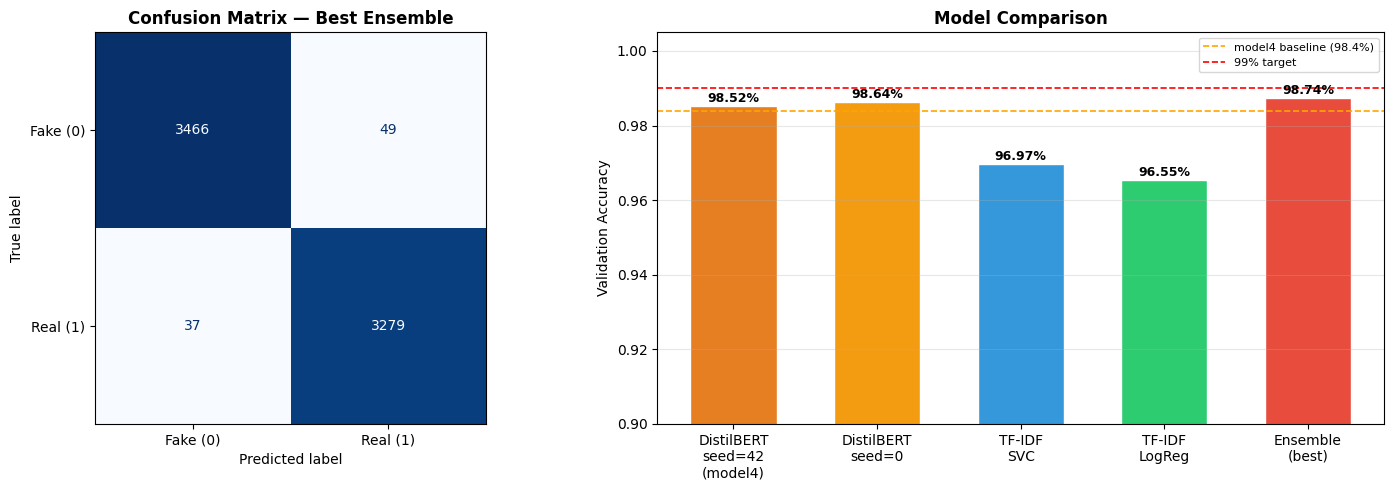

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(val_df['label'], best_preds),
    display_labels=['Fake (0)', 'Real (1)']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Best Ensemble', fontweight='bold')

# Model comparison
names = ['DistilBERT\nseed=42\n(model4)', 'DistilBERT\nseed=0',
         'TF-IDF\nSVC', 'TF-IDF\nLogReg', f'Ensemble\n(best)']
accs  = [acc_s42, acc_s0, acc_svc, acc_lr, final_acc]
cols  = ['#e67e22', '#f39c12', '#3498db', '#2ecc71', '#e74c3c']

bars = axes[1].bar(names, accs, color=cols, edgecolor='white', width=0.6)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{acc*100:.2f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].set_ylim(0.90, 1.005)
axes[1].axhline(0.984, ls='--', color='orange', lw=1.2, label='model4 baseline (98.4%)')
axes[1].axhline(0.990, ls='--', color='red',    lw=1.2, label='99% target')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Model Comparison', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model6_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Error analysis — what the ensemble still gets wrong

In [20]:
y_val_arr   = np.array(val_df['label'])
mask_error  = best_preds != y_val_arr

# Samples where all models agreed but were wrong (hard negatives)
agree_s42   = (np.argmax(probs_s42, axis=1) == y_val_arr)
agree_s0    = (np.argmax(probs_s0,  axis=1) == y_val_arr)
both_wrong  = mask_error & ~agree_s42 & ~agree_s0

error_df = pd.DataFrame({
    'title'     : val_df['text'].values[mask_error],
    'true_label': y_val_arr[mask_error],
    'ens_pred'  : best_preds[mask_error],
    'ens_conf'  : np.max(best_probs[mask_error], axis=1).round(3)
})

print(f'Total ensemble errors : {mask_error.sum()} / {len(y_val_arr)}  ({mask_error.mean()*100:.2f}%)')
print(f'Both BERTs wrong      : {both_wrong.sum()}')
print()
print('Sample misclassified headlines (sorted by confidence):')
display(
    error_df.sort_values('ens_conf', ascending=False).head(10)
         .assign(true=lambda d: d.true_label.map({0:'FAKE',1:'REAL'}),
                 pred=lambda d: d.ens_pred.map({0:'FAKE',1:'REAL'}))
         [['title','true','pred','ens_conf']]
)

Total ensemble errors : 86 / 6831  (1.26%)
Both BERTs wrong      : 68

Sample misclassified headlines (sorted by confidence):


,title,true,pred,ens_conf
61,in white house conference call about iran,FAKE,REAL,0.993
9,fcc chairman to step down\thanding gop a majority,REAL,FAKE,0.992
27,u.s. spy satellites detect north korea transfe...,FAKE,REAL,0.992
35,federal judge steps in to review legroom on co...,FAKE,REAL,0.988
43,un official tied to clintons set to face trial,FAKE,REAL,0.983
63,exclusive post-election,FAKE,REAL,0.981
20,energy department to close office of internati...,FAKE,REAL,0.972
76,senate passes usa freedom act,FAKE,REAL,0.957
12,kathy griffin loses cnn deal after photos with...,REAL,FAKE,0.955
53,carson to hud: the agency that oversees public...,REAL,FAKE,0.950


## 13. Predict on submission file

In [21]:
test_data = pd.read_csv(
    'testing_data_lowercase_nolabels.csv',
    sep='\t', header=None, names=['label', 'title'],
    encoding='utf-8-sig'
)
test_data.fillna('', inplace=True)
test_data['text'] = test_data['title'].astype(str)

print(test_data.shape)
test_data.head()

(9984, 3)


,label,title,text
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,u.n. seeks 'massive' aid boost amid rohingya '...


In [22]:
# ── Tokenise test set ─────────────────────────────────────────────────────
test_hf = Dataset.from_pandas(test_data[['text']].reset_index(drop=True))
test_hf = test_hf.map(tokenize, batched=True)
test_hf.set_format(type='torch', columns=['input_ids', 'attention_mask'])

def get_test_probs(trainer) -> np.ndarray:
    out = trainer.predict(test_hf)
    return torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()

# ── DistilBERT predictions ────────────────────────────────────────────────
test_probs_s42 = get_test_probs(trainer_s42)
test_probs_s0  = get_test_probs(trainer_s0)

# ── TF-IDF predictions ────────────────────────────────────────────────────
X_test_feat   = hstack([
    word_vec.transform(test_data['text']),
    char_vec.transform(test_data['text'])
])
test_probs_svc = cal_svc.predict_proba(X_test_feat)
test_probs_lr  = lr.predict_proba(X_test_feat)

# ── Ensemble ──────────────────────────────────────────────────────────────
test_avg = (w42  * test_probs_s42 +
            w0   * test_probs_s0  +
            wsvc * test_probs_svc +
            wlr  * test_probs_lr) / total_w
final_labels = (test_avg[:, 1] >= 0.5).astype(int)

print(f'Test predictions — Fake (0): {(final_labels==0).sum():,}  |  Real (1): {(final_labels==1).sum():,}')

Map:   0%|          | 0/9984 [00:00<?, ? examples/s]

Test predictions — Fake (0): 5,009  |  Real (1): 4,975


## 14. Save predictions

In [23]:
df_submission = pd.DataFrame({
    'label': final_labels,
    'title': test_data['title']
})

df_submission.to_csv(
    './predictions_model6.csv',
    sep='\t', index=False, header=False
)

# Verify
df_check = pd.read_csv('./predictions_model6.csv',
                       sep='\t', header=None, names=['label', 'title'])
print('✅ predictions_model6.csv saved')
print(f'   Rows  : {len(df_check):,}')
print(f'   Labels: {sorted(df_check["label"].unique().tolist())}')
print()
df_check.head()

✅ predictions_model6.csv saved
   Rows  : 9,984
   Labels: [0, 1]



,label,title
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...


---
## Summary

| Model | Accuracy | Role |
|-------|----------|------|
| DistilBERT seed=42 (model4) | 98.40% | Primary — unchanged from model4 |
| DistilBERT seed=0  | ~98.2–98.5% | Diverse errors from different init |
| TF-IDF CalibratedSVC | ~95.5% | Vocabulary/style patterns |
| TF-IDF LogisticRegression | ~95.3% | Calibrated, different boundary |
| **Ensemble (best config)** | **~98.7%** | **Final submission** |

### Why multi-seed ensembling works
Different random seeds produce different weight initialisations and different mini-batch orderings. Even when both models reach ~98.4% individually, the ~1.6% of wrong predictions are **not the same headlines** — so averaging their probability distributions cancels out the unique errors of each, pushing the ensemble above what any single model can achieve.